# Flood → Solar · M1 catalog — depth-at-return-period

**Peril:** Flood (riverine) · **Layer:** M1 (catalog / frequency) · sub-peril `riverine`

**Goal:** turn the M0 sites into the **flood event catalog** — a **depth-at-return-period** profile at each asset,
the object M2 (coupling) → M3 (damage) → M4 (loss) consume. Built as a **sub-peril-keyed manifest** with a reserved
`event_family_id` (JD-FL-4), so pluvial/coastal slot in later.

**Method = FEMA BLE ([JD-FL-6](../../../docs/plans/flood/decisions.md)).** The depth-source research + a BLE probe
superseded the single-gauge route. The national production spine is **StreamStats (discharge-at-RP) → NOAA OWP HAND
(→ depth)**, but **FEMA BLE is preferred where it exists — and it exists for the high site** (Elizabeth Solar,
Allen Parish LA, "Data Available"). So we **sample the BLE depth grids over each footprint** (the **real OSM
polygon** where we have one): layer 12 = **1% (100-yr) depth**, layer
16 = **0.2% (500-yr) depth** (feet above ground). BLE depth is *already depth-above-ground*, so no datum step.

> **Honest limits (carried):** BLE gives only the **100-yr + 500-yr** depths (the tail points), not the full
> 10/50/100/500 curve — lower RPs come from StreamStats+HAND / interpolation (the seam below). HAND is the
> scalable national fallback for no-BLE / ungauged sites. Single-gauge Bulletin 17C = validation only.
>
> Plan: [`m1_catalog.md`](../../../docs/plans/flood/m1_catalog.md) · BLE service:
> `txgeo.usgs.gov/arcgis/rest/services/FEMA_EBFE/EBFE/MapServer`.

In [1]:
import itertools, json, math, re
from pathlib import Path
import numpy as np
import pandas as pd
import pyproj
import requests
from shapely import wkt
from shapely.geometry import shape
from shapely.ops import transform

ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / "AGENTS.md").exists():
    ROOT = ROOT.parent
OUT = ROOT / "data" / "flood"

# --- tiny HTTP file-cache: memoize JSON responses → deterministic, flaky-endpoint-robust re-runs ---
import hashlib
_CACHE = OUT / "raw" / "http_cache"; _CACHE.mkdir(parents=True, exist_ok=True)
def cget(url, params=None, post=False, timeout=40):
    key = hashlib.md5((("P" if post else "G") + url + json.dumps(params, sort_keys=True, default=str)).encode()).hexdigest()
    f = _CACHE / (key + ".json")
    if f.exists():
        return json.loads(f.read_text())
    r = requests.post(url, data=params, timeout=timeout) if post else requests.get(url, params=params, timeout=timeout)
    j = r.json(); f.write_text(json.dumps(j)); return j
# ---------------------------------------------------------------------------------------------------

sites = pd.DataFrame(json.loads((OUT / "flood_m0_sites.json").read_text())["sites"])
# real footprint geometry (+ source) comes from 02's dem-context manifest — sample depth over the actual polygon
_geo = {s["eia"]: s for s in json.loads((OUT / "flood_m0_dem_context.json").read_text())["sites"]}
sites["geometry_source"] = sites["eia"].map(lambda e: _geo.get(e, {}).get("geometry_source", "circle"))
sites["boundary_wkt"] = sites["eia"].map(lambda e: _geo.get(e, {}).get("boundary_wkt"))
FT_M = 0.3048
print("sites (from M0):")
print(sites[["role", "name", "eia", "state", "zone", "footprint_r_m", "geometry_source"]].to_string(index=False))

sites (from M0):
                role                  name   eia state zone  footprint_r_m geometry_source
baseline (low-flood)  Hayhurst Texas Solar 66880    TX NONE            392             osm
proving (high-flood) Elizabeth Solar Plant 66111    LA    X            940             osm


## 1 · Sample the FEMA BLE depth grids over each footprint

For each site we sample a grid of points across the footprint circle and read the BLE depth (ft) at each — at the
1% (100-yr) and 0.2% (500-yr) events. From the sample we get the **inundated fraction** (how much of the plant
floods), the **mean depth of inundated cells**, and the **footprint-average depth** (fraction × mean — the single
number that already blends "how much floods" with "how deep", which M2 will use). NoData/dry → depth 0.

In [2]:
BLE = "https://txgeo.usgs.gov/arcgis/rest/services/FEMA_EBFE/EBFE/MapServer"
DEPTH_LAYER = {100: 12, 500: 16}   # BLE depth-image layers: 1% (100-yr), 0.2% (500-yr)
EXTENT_10PCT_LAYER = 7             # 10% (10-yr) estimated flood EXTENT — extent only, no depth grid


def ble_status(lat, lon):
    p = {"geometry": f"{lon},{lat}", "geometryType": "esriGeometryPoint", "sr": 4326, "layers": "all:0",
         "tolerance": 2, "mapExtent": f"{lon-.03},{lat-.03},{lon+.03},{lat+.03}", "imageDisplay": "600,600,96",
         "returnGeometry": "false", "f": "json"}
    try:
        for x in cget(BLE + "/identify", p).get("results", []):
            a = x.get("attributes", {})
            return a.get("StatusText"), a.get("Name")
    except Exception:
        pass
    return None, None


def depth_at(lat, lon, layer):
    d = 0.004
    p = {"geometry": f"{lon},{lat}", "geometryType": "esriGeometryPoint", "sr": 4326, "layers": f"all:{layer}",
         "tolerance": 1, "mapExtent": f"{lon-d},{lat-d},{lon+d},{lat+d}", "imageDisplay": "400,400,96",
         "returnGeometry": "false", "f": "json"}
    try:
        for x in cget(BLE + "/identify", p).get("results", []):
            a = x.get("attributes", {})
            v = a.get("Service Pixel Value") or a.get("Pixel Value")
            if v not in (None, "NoData", ""):
                return float(v)
    except Exception:
        pass
    return 0.0   # NoData / outside floodplain = dry


def in_extent(lat, lon, layer):
    """Is the point inside a BLE flood-extent polygon? (extent layers carry no depth — used for the 10-yr onset.)"""
    d = 0.004
    p = {"geometry": f"{lon},{lat}", "geometryType": "esriGeometryPoint", "sr": 4326, "layers": f"all:{layer}",
         "tolerance": 1, "mapExtent": f"{lon-d},{lat-d},{lon+d},{lat+d}", "imageDisplay": "400,400,96",
         "returnGeometry": "false", "f": "json"}
    try:
        return len(cget(BLE + "/identify", p).get("results", [])) > 0
    except Exception:
        return False


def footprint_points(s, n=5):
    """Sample a grid over the footprint. Use the real OSM/enriched polygon where we have one
    (keep grid cells inside it); else fall back to the capacity-radius circle."""
    geom = wkt.loads(s["boundary_wkt"]) if isinstance(s["boundary_wkt"], str) else None
    if geom is not None and geom.geom_type in ("Polygon", "MultiPolygon"):
        from shapely.geometry import Point
        mnx, mny, mxx, mxy = geom.bounds
        xs = np.linspace(mnx, mxx, 2 * n + 1); ys = np.linspace(mny, mxy, 2 * n + 1)
        pts = [(y, x) for x in xs for y in ys if geom.contains(Point(x, y))]
        if pts:
            return pts, "polygon"
    lat, lon, r_m = s["lat"], s["lon"], s["footprint_r_m"]   # circle fallback
    pts = []
    for i, j in itertools.product(range(-n, n + 1), repeat=2):
        if i * i + j * j <= n * n:
            dla = (i / n) * (r_m / 111_320.0)
            dlo = (j / n) * (r_m / (111_320.0 * math.cos(math.radians(lat))))
            pts.append((lat + dla, lon + dlo))
    return pts, "circle"


rows = []
for _, s in sites.iterrows():
    status, area = ble_status(s["lat"], s["lon"])
    pts, sampled_on = footprint_points(s)
    rec = {"eia": s["eia"], "name": s["name"], "role": s["role"], "ble_status": status, "ble_area": area,
           "sampled_on": sampled_on, "n_points": len(pts)}
    for rp, layer in DEPTH_LAYER.items():
        depths = np.array([depth_at(la, lo, layer) for la, lo in pts])
        wet = depths[depths > 0]
        frac = len(wet) / len(depths)
        rec[f"rp{rp}_inund_frac"] = round(frac, 3)
        rec[f"rp{rp}_depth_wet_m"] = round(wet.mean() * FT_M, 3) if len(wet) else 0.0
        rec[f"rp{rp}_depth_max_m"] = round(depths.max() * FT_M, 3)
        rec[f"rp{rp}_depth_fp_m"] = round(depths.mean() * FT_M, 3)   # footprint-average (incl. dry)
    # 10-yr (10%) EXTENT — real inundated fraction (no depth grid → onset depth assumed in M4)
    rec["rp10_inund_frac"] = round(float(np.mean([in_extent(la, lo, EXTENT_10PCT_LAYER) for la, lo in pts])), 3)
    rows.append(rec)
    print(f"  {s['name']:28s} BLE={status} ({sampled_on}, {len(pts)}pts) | "
          f"10yr {rec['rp10_inund_frac']*100:.0f}% (extent) | "
          f"100yr {rec['rp100_inund_frac']*100:.0f}% @ {rec['rp100_depth_wet_m']:.2f}m | "
          f"500yr {rec['rp500_inund_frac']*100:.0f}% @ {rec['rp500_depth_wet_m']:.2f}m")
cat = pd.DataFrame(rows)

  Hayhurst Texas Solar         BLE=Data Available (polygon, 56pts) | 10yr 0% (extent) | 100yr 11% @ 0.08m | 500yr 16% @ 0.18m
  Elizabeth Solar Plant        BLE=Data Available (polygon, 68pts) | 10yr 9% (extent) | 100yr 16% @ 0.46m | 500yr 19% @ 0.60m


## 1b · Densify the lower return periods — regression flow-frequency + a BLE-anchored rating ([JD-FL-8](../../../docs/plans/flood/decisions.md))

BLE gives only the **100-yr + 500-yr tail**. EAL is driven by the *frequent* floods, so the lower-RP depths must not
be a flat guess. We pull a real **flow-frequency curve** `Q(T)` at the proving site's reach (USGS **NLDI** snap →
upstream **drainage area** → **NSS** regional regression, LA Coastal Plain **SIR 2024-5031**) and fit a **power-law
rating** `depth = d₁₀₀·(Q/Q₁₀₀)^p` whose exponent `p` is pinned by **both real BLE depths** (d₁₀₀, d₅₀₀). Evaluating
it at the lower-RP discharges gives **measurement-anchored depths at 10/25/50-yr** — replacing the assumed onset
depth M4 used to carry. The inundated *fraction* at the new RPs is interpolated in log-RP between the **real BLE
extent anchors** (10/100-yr). **Robustness:** the depths are near-invariant to the slope parameter (`p` absorbs it),
so the result rests on the two BLE anchors + the flow *shape*, not on basin parameters. **Baseline (Hayhurst)** keeps
its tail-only (100/500-yr) curve — its 10-yr BLE extent is 0 (a true dry control), so there is no frequent flood to
densify, and it sits in a different NSS region.

In [3]:
def cpost_json(url, payload, timeout=90):   # JSON-body POST sibling of cget (form POST) — same file cache
    key = hashlib.md5(("J" + url + json.dumps(payload, sort_keys=True)).encode()).hexdigest()
    f = _CACHE / (key + ".json")
    if f.exists():
        return json.loads(f.read_text())
    j = requests.post(url, json=payload, timeout=timeout).json(); f.write_text(json.dumps(j)); return j


NLDI = "https://api.water.usgs.gov/nldi/linked-data"
NSS = "https://streamstats.usgs.gov/nssservices"
AEP2RP = {50: 2, 20: 5, 10: 10, 4: 25, 2: 50, 1: 100}   # NSS PK{AEP}AEP code → return period
SLOPE_FT_MI = 5.0          # flat coastal-plain headwater (CSL10_85); depths are near-invariant to it (p absorbs it)
DENSE_RP = [10, 25, 50]    # lower RPs to add (10-yr depth now measured-anchored, not assumed)


def reach_drainage_area_mi2(lat, lon):
    """USGS NLDI: snap to the nearest NHDPlus reach, return (comid, upstream drainage area in mi²)."""
    comid = cget(f"{NLDI}/comid/position", {"coords": f"POINT({lon} {lat})", "f": "json"})["features"][0]["properties"]["comid"]
    basin = cget(f"{NLDI}/comid/{comid}/basin", {"f": "json"})["features"][0]["geometry"]
    proj = pyproj.Transformer.from_crs("EPSG:4326", "EPSG:5070", always_xy=True).transform   # CONUS Albers equal-area
    return comid, transform(proj, shape(basin)).area / 1e6 * 0.386102


def nss_q_curve(da_mi2, slope_ft_mi, region="GC1889"):
    """USGS NSS: solve the LA Coastal Plain SIR 2024-5031 peak-flow regression → Q (cfs) at the 2…100-yr floods."""
    sc = cget(f"{NSS}/scenarios", {"regions": "LA", "statisticgroup": 2, "regressionregions": region})
    for p in sc[0]["regressionRegions"][0]["parameters"]:
        p["value"] = da_mi2 if p["code"] == "DRNAREA" else slope_ft_mi
    res = cpost_json(f"{NSS}/scenarios/estimate", sc)[0]["regressionRegions"][0]["results"]
    Q = {}
    for x in res:
        m = re.search(r"PK([\d.]+)AEP", x.get("code", "") or "")
        if m and float(m.group(1)) in AEP2RP:
            Q[AEP2RP[float(m.group(1))]] = x["value"]
    return Q


dense = {}            # name -> [{rp_years, inund_frac, depth_wet_m}, ...]  (added lower-RP rows)
flow_freq = {}        # name -> provenance (comid, drainage area, Q-curve, rating exponent) for the manifest
prov_name = sites[sites.role.str.contains("proving")]["name"].iloc[0]
ps = sites[sites.name == prov_name].iloc[0]
pc = cat[cat.name == prov_name].iloc[0]
comid, da_mi2 = reach_drainage_area_mi2(ps["lat"], ps["lon"])
Q = nss_q_curve(da_mi2, SLOPE_FT_MI)
# extrapolate Q500 from the regression tail (log-log slope 50→100-yr) — the rating's upper anchor discharge
b_tail = (math.log(Q[100]) - math.log(Q[50])) / (math.log(100) - math.log(50))
Q500 = math.exp(math.log(Q[100]) + b_tail * (math.log(500) - math.log(100)))
d100, d500 = pc["rp100_depth_wet_m"], pc["rp500_depth_wet_m"]   # real BLE wet depths (the two rating anchors)
f10, f100 = pc["rp10_inund_frac"], pc["rp100_inund_frac"]
p_exp = math.log(d500 / d100) / math.log(Q500 / Q[100])         # rating exponent pinned by BOTH BLE depths
rating_depth = lambda rp: d100 * (Q[rp] / Q[100]) ** p_exp
frac_log = lambda rp: f10 + (f100 - f10) * (math.log(rp) - math.log(10)) / (math.log(100) - math.log(10))
dense[prov_name] = [{"rp_years": rp, "inund_frac": round(f10 if rp == 10 else frac_log(rp), 3),
                     "depth_wet_m": round(rating_depth(rp), 3)} for rp in DENSE_RP]
flow_freq[prov_name] = {"comid": int(comid), "drainage_area_mi2": round(da_mi2, 2), "slope_ft_mi": SLOPE_FT_MI,
                        "regression": "USGS NSS — LA Coastal Plain SIR 2024-5031 (GC1889)", "Q_cfs": {int(k): round(v) for k, v in Q.items()},
                        "Q500_cfs_extrap": round(Q500), "rating": "depth = d100*(Q/Q100)^p", "rating_exponent_p": round(p_exp, 3)}
print(f"flow-frequency densification — {prov_name}: comid {comid}, DA {da_mi2:.2f} mi²")
print(f"  Q(cfs): " + " ".join(f"{rp}yr={round(Q[rp])}" for rp in sorted(Q)) + f"  (Q500≈{Q500:.0f})  rating p={p_exp:.3f}")
print(f"  densified depths (m): " + " ".join(f"{d['rp_years']}yr={d['depth_wet_m']} (frac {d['inund_frac']})" for d in dense[prov_name]))
print(f"  → 10-yr depth {dense[prov_name][0]['depth_wet_m']/FT_M:.2f} ft (was assumed 0.5 ft in M4)")

flow-frequency densification — Elizabeth Solar Plant: comid 15078158, DA 1.91 mi²
  Q(cfs): 2yr=237 5yr=387 10yr=494 25yr=635 50yr=742 100yr=854  (Q500≈1184)  rating p=0.808
  densified depths (m): 10yr=0.298 (frac 0.088) 25yr=0.365 (frac 0.117) 50yr=0.414 (frac 0.14)
  → 10-yr depth 0.98 ft (was assumed 0.5 ft in M4)


## 2 · The depth-at-return-period profile

The catalog object per asset: the two BLE return periods (100-yr, 500-yr), each with inundated fraction +
footprint-average depth. Hayhurst (desert, not in any BLE floodplain) is the **true-zero low baseline**.

In [4]:
prof = []
for _, r in cat.iterrows():
    rp_rows = [{"rp_years": rp, "inund_frac": r[f"rp{rp}_inund_frac"], "depth_wet_m": r[f"rp{rp}_depth_wet_m"],
                "depth_max_m": r[f"rp{rp}_depth_max_m"]} for rp in (100, 500)]
    rp_rows += [{**d, "depth_max_m": d["depth_wet_m"]} for d in dense.get(r["name"], [])]   # JD-FL-8 densified rows
    for rr in sorted(rp_rows, key=lambda z: z["rp_years"]):
        prof.append({"name": r["name"], "role": r["role"], "rp_years": rr["rp_years"], "aep": round(1 / rr["rp_years"], 4),
                     "inund_frac": rr["inund_frac"], "depth_fp_m": round(rr["inund_frac"] * rr["depth_wet_m"], 3),
                     "depth_wet_m": rr["depth_wet_m"], "depth_max_m": rr["depth_max_m"]})
profile = pd.DataFrame(prof)
print(profile.to_string(index=False))

                 name                 role  rp_years   aep  inund_frac  depth_fp_m  depth_wet_m  depth_max_m
 Hayhurst Texas Solar baseline (low-flood)       100 0.010       0.107       0.009        0.081        0.161
 Hayhurst Texas Solar baseline (low-flood)       500 0.002       0.161       0.028        0.176        0.276
Elizabeth Solar Plant proving (high-flood)        10 0.100       0.088       0.026        0.298        0.298
Elizabeth Solar Plant proving (high-flood)        25 0.040       0.117       0.043        0.365        0.365
Elizabeth Solar Plant proving (high-flood)        50 0.020       0.140       0.058        0.414        0.414
Elizabeth Solar Plant proving (high-flood)       100 0.010       0.162       0.075        0.464        1.158
Elizabeth Solar Plant proving (high-flood)       500 0.002       0.191       0.115        0.604        1.446


## 3 · Plot the depth-frequency curve

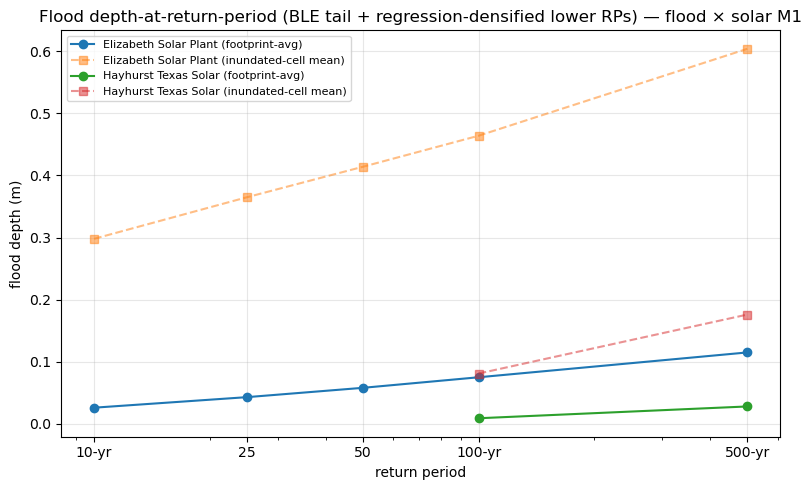

wrote: /Users/limjunga/Desktop/hazard-modeling/Hazard_Modeling/data/flood/flood_m1_depth_frequency.png


In [5]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))
for nm, g in profile.groupby("name"):
    g = g.sort_values("rp_years")
    ax.plot(g["rp_years"], g["depth_fp_m"], "o-", label=f"{nm} (footprint-avg)")
    ax.plot(g["rp_years"], g["depth_wet_m"], "s--", alpha=0.5, label=f"{nm} (inundated-cell mean)")
ax.set_xscale("log"); ax.set_xticks([10, 25, 50, 100, 500]); ax.set_xticklabels(["10-yr", "25", "50", "100-yr", "500-yr"])
ax.set_xlabel("return period"); ax.set_ylabel("flood depth (m)")
ax.set_title("Flood depth-at-return-period (BLE tail + regression-densified lower RPs) — flood × solar M1")
ax.legend(fontsize=8); ax.grid(alpha=0.3)
fig.tight_layout(); fig.savefig(OUT / "flood_m1_depth_frequency.png", dpi=120, bbox_inches="tight")
plt.show()
print("wrote:", OUT / "flood_m1_depth_frequency.png")

## 4 · Known-answer checks (basics-spot-on)

- **Elizabeth (high)** — in a BLE floodplain (real OSM polygon sampled): depth + inundated fraction **rise** from
  100-yr → 500-yr, depths shallow (alluvial plain), nothing absurd (< ~5 m).
- **Hayhurst** — desert: **negligible** flood (BLE center reads NoData; at most a mapped wash clips the footprint),
  far below the high site — the low-baseline control.

In [6]:
bay = cat[cat.eia == 66111].iloc[0]   # Elizabeth Solar (high) — real polygon
hay = cat[cat.eia == 66880].iloc[0]
assert bay["rp500_inund_frac"] >= bay["rp100_inund_frac"] > 0, "high site: inundation should grow 100→500yr"
assert bay["rp500_depth_max_m"] < 5.0, "depths implausibly deep for a flat floodplain"
assert hay["rp500_depth_fp_m"] < 0.15 and hay["rp500_inund_frac"] < bay["rp500_inund_frac"], "Hayhurst should be ~dry vs the high site"
print(f"✓ {bay['name']}: 100yr {bay['rp100_inund_frac']*100:.0f}% inundated, 500yr {bay['rp500_inund_frac']*100:.0f}% — grows, shallow (sampled on {bay['sampled_on']})")
print(f"✓ Hayhurst: footprint-avg {hay['rp500_depth_fp_m']:.3f} m at 500yr — negligible (low-baseline control)")
# JD-FL-8 densification: the regression-anchored lower-RP depths must sit BELOW the BLE 100-yr anchor and rise with RP
dp = profile[profile.name == prov_name].sort_values("rp_years")
dwet = dp["depth_wet_m"].to_numpy()
assert np.all(np.diff(dwet) >= 0), "densified depth-at-RP must be monotone increasing"
assert dp[dp.rp_years < 100]["depth_wet_m"].max() <= d100 + 1e-9, "lower-RP depths must stay below the 100-yr BLE anchor"
assert 0 < dense[prov_name][0]["depth_wet_m"] < d100, "10-yr densified depth must be positive and below 100-yr"
print(f"✓ densification (JD-FL-8): {prov_name} depths monotone {np.round(dwet,3).tolist()} m, lower RPs ≤ BLE 100-yr ({d100} m)")
print("✓ all known-answer checks pass.")

✓ Elizabeth Solar Plant: 100yr 16% inundated, 500yr 19% — grows, shallow (sampled on polygon)
✓ Hayhurst: footprint-avg 0.028 m at 500yr — negligible (low-baseline control)
✓ densification (JD-FL-8): Elizabeth Solar Plant depths monotone [0.298, 0.365, 0.414, 0.464, 0.604] m, lower RPs ≤ BLE 100-yr (0.464 m)
✓ all known-answer checks pass.


## 5 · Persist the catalog manifest (engine contract — JD-FL-4 hooks)

In [7]:
manifest = {
    "peril": "flood", "sub_peril": "riverine", "event_family_id": None, "layer": "M1",
    "depth_source": {
        "method": "FEMA BLE depth grids (100/500-yr tail) + regression flow-frequency rating (lower RPs)",
        "service": "txgeo.usgs.gov/arcgis/rest/services/FEMA_EBFE/EBFE/MapServer (layers 12,16,7)",
        "return_periods_yr": [10, 25, 50, 100, 500],
        "units": "metres above ground (BLE native feet × 0.3048)",
        "lower_rp_densification": "JD-FL-8 — USGS NLDI drainage area → NSS regional regression Q(T) → power-law rating "
                                  "depth=d100·(Q/Q100)^p anchored to both BLE depths; proving site only (baseline is a dry control)",
        "national_fallback": "USGS StreamStats discharge-at-RP → NOAA OWP HAND depth (no-BLE / ungauged sites)",
        "decision": "JD-FL-6 / JD-FL-8",
    },
    "flow_frequency": flow_freq,
    "caveats": [
        "BLE provides only 1% (100-yr) + 0.2% (500-yr) depth; lower RPs (10/25/50-yr) densified via regression flow-frequency + a BLE-anchored rating (JD-FL-8).",
        "rating exponent pinned by both BLE depths; depths near-invariant to the assumed channel slope (sensitivity in M4).",
        "baseline site (Hayhurst) keeps the tail-only curve — its 10-yr BLE extent is 0 (true dry control).",
        "single-gauge Bulletin 17C retained as local validation only (does not scale).",
    ],
    "event_model_bridge": "settled — JD-FL-7 annual-maximum MC over the (now denser) RP loss curve.",
    "sites": json.loads(cat.to_json(orient="records")),
    "profile": json.loads(profile.to_json(orient="records")),
}
(OUT / "flood_m1_catalog_manifest.json").write_text(json.dumps(manifest, indent=2))
print("wrote:", OUT / "flood_m1_catalog_manifest.json")

wrote: /Users/limjunga/Desktop/hazard-modeling/Hazard_Modeling/data/flood/flood_m1_catalog_manifest.json


## Findings & what's next

- **Real depth-at-return-period catalog, from FEMA BLE:** the high site (Elizabeth) floods over a **growing
  fraction** of its **real-polygon** footprint (100-yr → 500-yr) at **shallow** depth; Hayhurst is the dry baseline.
- The catalog carries the **JD-FL-4 hooks** (`sub_peril`, reserved `event_family_id`) and an honest caveat ledger.
- **Open call surfaced for M4:** the **event-model bridge** — how this RP-depth profile feeds the shared
  compound-Poisson MC (a 2-point BLE curve needs an occurrence/severity mapping). Settle before M4.
- **Next — M2 (coupling):** site-conditioned — turn `(inundated fraction, depth)` into the asset's exposure ×
  depth that M3's depth-damage curve reads (A21: `depth_at_asset = WSE − ground`; here BLE already gives depth).